# Reto 3

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from pathlib import Path

PROJECT_ROOT = Path('/content/drive/MyDrive/ModeladoPredictivo2026')
sys.path.insert(0, str(PROJECT_ROOT))

from src.dataset import (
    PAD_IDX, UNK_IDX,
    build_vocabulary,
    load_glove,
    FakeNewsDataset,
    create_dataloaders,
)
from src.model import TextCNN
from src.train import train_model
from src.evaluate import evaluate_model, get_predictions, plot_confusion_matrix, plot_training_curves

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)

print(f'Dispositivo : {device}')
print(f'PyTorch     : {torch.__version__}')
print(f'CUDA        : {torch.cuda.is_available()}')

Dispositivo : cuda
PyTorch     : 2.11.0+cu128
CUDA        : True


In [ ]:
# Cargar datos limpios
DATA_DIR   = PROJECT_ROOT / 'data'
clean_path = DATA_DIR / 'processed' / 'wellfake_clean.csv'
raw_path   = DATA_DIR / 'raw' / 'WELFake_Dataset.csv'

if clean_path.exists():
    df = pd.read_csv(clean_path)
    print(f'Datos limpios cargados desde: {clean_path}')
else:
    df = pd.read_csv(raw_path)
    df = df.dropna(subset=['text', 'label'])
    df['text'] = df['text'].astype(str).str.lower().str.strip()
    print(f'Datos originales cargados desde: {raw_path}')

print(f'\nForma del DataFrame: {df.shape}')
print(f'Columnas: {list(df.columns)}')
print(f'\nDistribución de etiquetas:')
print(df['label'].value_counts())

Datos limpios cargados desde: /content/drive/MyDrive/ModeladoPredictivo2026/data/processed/wellfake_clean.csv

Forma del DataFrame: (61394, 5)
Columnas: ['title', 'text', 'label', 'title_len', 'text_len']

Distribución de etiquetas:
label
0    34237
1    27157
Name: count, dtype: int64


In [ ]:
!pip install contractions -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 12.5 MB/s eta 0:00:00


In [ ]:
import re, unicodedata, contractions, spacy
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])
POS_KEEP = {'NOUN', 'PROPN', 'VERB', 'ADJ', 'ADV'}

In [ ]:
def clean_text(text: str) -> str:
    # P1: Contracciones (ANTES de quitar signos)
    try:
        text = contractions.fix(text)
    except IndexError:
        pass
    text = text.lower()

    # P2: Lematización + filtro POS
    doc = nlp(text)
    tokens = [
        t.lemma_ for t in doc
        if t.pos_ in POS_KEEP
        and not t.is_space
        and len(t.lemma_) > 1
    ]
    text = " ".join(tokens)

    # P3: Signos residuales + cirílico (AL FINAL)
    text = re.sub(r'http\S+|www\.\S+', '', text) # URLs
    text = re.sub(r'[@#]\w+', '', text) # menciones/hashtags
    text = re.sub(r'[\u0400-\u04FF]+', '', text) # caracteres cirílicos (ruso)
    text = re.sub(r'[^\w\s]', ' ', text) # puntuación residual
    text = re.sub(r'\b\d+\b', '', text) # dígitos aislados
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [ ]:
df.columns

Index(['title', 'text', 'label', 'title_len', 'text_len'], dtype='object')

In [ ]:
def fix_contractions(text):
    try:
        return contractions.fix(text)
    except IndexError:
        return text

def limpiar_signos(text):
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'[@#]\w+', '', text)
    text = re.sub(r'[\u0400-\u04FF]+', '', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\b\d+\b', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def aplicar_pipeline(serie):
    """Aplica P1→P2→P3 a una Series de texto."""
    pre = [fix_contractions(t).lower() for t in serie.astype(str)]
    limpios = []
    for doc in nlp.pipe(pre, batch_size=512):
        tokens = [t.lemma_ for t in doc if t.pos_ in POS_KEEP and not t.is_space and len(t.lemma_) > 1]
        limpios.append(" ".join(tokens))
    return [limpiar_signos(t) for t in limpios]

print("Limpiando text...")
df['text'] = aplicar_pipeline(df['text'])
print("Limpiando title...")
df['title'] = aplicar_pipeline(df['title'])

# Combinar title + text en una sola columna
df['text_combined'] = df['title'] + ' ' + df['text']

print("Limpieza completa")
print(f"Ejemplo text    : {df['text'].iloc[0][:80]}")
print(f"Ejemplo title   : {df['title'].iloc[0][:80]}")
print(f"Ejemplo combined: {df['text_combined'].iloc[0][:80]}")


Limpiando text...
Limpiando title...
Limpieza completa
Ejemplo text    : comment expect barack obama member fyf911 fukyoflag blacklivesmatt movement call
Ejemplo title   : law enforcement high alert follow threat cop white 11by blacklivesmatter fyf911 
Ejemplo combined: law enforcement high alert follow threat cop white 11by blacklivesmatter fyf911 


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Normalizar features numéricas
scaler = MinMaxScaler()
df[['title_len_norm', 'text_len_norm']] = scaler.fit_transform(df[['title_len', 'text_len']])

# Split 80/10/10 estratificado
train_df, temp_df = train_test_split(df, test_size=0.20, random_state=42, stratify=df['label'])
val_df,  test_df  = train_test_split(temp_df, test_size=0.50, random_state=42, stratify=temp_df['label'])

train_texts  = train_df['text_combined'].tolist()
val_texts    = val_df['text_combined'].tolist()
test_texts   = test_df['text_combined'].tolist()
train_labels = train_df['label'].tolist()
val_labels   = val_df['label'].tolist()
test_labels  = test_df['label'].tolist()

# Features numéricas como tensores (title_len + text_len normalizados)
train_feats = torch.tensor(train_df[['title_len_norm', 'text_len_norm']].values, dtype=torch.float32)
val_feats   = torch.tensor(val_df[['title_len_norm', 'text_len_norm']].values,   dtype=torch.float32)
test_feats  = torch.tensor(test_df[['title_len_norm', 'text_len_norm']].values,  dtype=torch.float32)

print(f'Train : {len(train_texts):,} muestras')
print(f'Val   : {len(val_texts):,} muestras')
print(f'Test  : {len(test_texts):,} muestras')
print(f'train_feats.shape : {train_feats.shape}  <- (N, 2) title_len + text_len')

# Vocabulario SOLO con train
MAX_VOCAB = 20_000
word2idx  = build_vocabulary(train_texts, max_vocab=MAX_VOCAB)
VOCAB_SIZE = len(word2idx)
print(f'\nVocabulario: {VOCAB_SIZE:,} tokens')


Train : 49,115 muestras
Val   : 6,139 muestras
Test  : 6,140 muestras
train_feats.shape : torch.Size([49115, 2])  <- (N, 2) title_len + text_len

Vocabulario: 20,002 tokens


In [ ]:
MAX_LEN    = 200
BATCH_SIZE = 64

train_loader, val_loader, test_loader = create_dataloaders(
    train_data=(train_texts, train_labels),
    val_data  =(val_texts,   val_labels),
    test_data =(test_texts,  test_labels),
    word2idx  =word2idx,
    batch_size=BATCH_SIZE,
    max_len   =MAX_LEN,
)

# Verificar dimensiones
batch_texts_sample, batch_labels_sample = next(iter(train_loader))
print(f'batch_texts.shape  : {batch_texts_sample.shape}   <- esperado (64, 200)')
print(f'batch_labels.shape : {batch_labels_sample.shape}    <- esperado (64,)')
print(f'\nBatches - Train: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

DataLoaders creados:
  Entrenamiento: 49,115 muestras -> 768 batches
  Validacion:    6,139 muestras -> 96 batches
  Prueba:        6,140 muestras -> 96 batches
  Batch size: 64 | Max len: 200
batch_texts.shape  : torch.Size([64, 200])   <- esperado (64, 200)
batch_labels.shape : torch.Size([64])    <- esperado (64,)

Batches - Train: 768 | Val: 96 | Test: 96


In [ ]:
EMBED_DIM  = 100
GLOVE_PATH = PROJECT_ROOT / "data" / 'embeddings' / 'glove.6B.50d.txt'

if GLOVE_PATH.exists():
    embedding_matrix = load_glove(str(GLOVE_PATH), word2idx, embed_dim=EMBED_DIM)
    print(f'GloVe cargado: {embedding_matrix.shape}')
    print(f'Vector de <PAD> (ceros): {embedding_matrix[PAD_IDX][:5]}')
else:
    print(f'Archivo GloVe no encontrado en: {GLOVE_PATH}')
    embedding_matrix = np.random.normal(scale=0.6, size=(VOCAB_SIZE, EMBED_DIM)).astype(np.float32)
    embedding_matrix[PAD_IDX] = np.zeros(EMBED_DIM)


GloVe cargado: 0 / 20,002 palabras encontradas (0.0% de cobertura)
GloVe cargado: (20002, 100)
Vector de <PAD> (ceros): [0. 0. 0. 0. 0.]


# Reto 4

In [ ]:
# Hiperparámetros del reto
NUM_FILTERS  = 100
KERNEL_SIZES = [3, 4, 5]
DROPOUT      = 0.5

# Modelo 1: embeddings ALEATORIOS
torch.manual_seed(42)
model_random = TextCNN(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    num_filters=NUM_FILTERS,
    kernel_sizes=KERNEL_SIZES,
    dropout=DROPOUT,
    num_classes=1,
    pretrained_embeddings=None,
).to(device)

# Modelo 2: embeddings GloVe PREENTRENADOS
torch.manual_seed(42)
model_glove = TextCNN(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    num_filters=NUM_FILTERS,
    kernel_sizes=KERNEL_SIZES,
    dropout=DROPOUT,
    num_classes=1,
    pretrained_embeddings=embedding_matrix,
).to(device)

print('=== Arquitectura TextCNN ===')
print(model_random)
print(f'\nParámetros totales     : {sum(p.numel() for p in model_random.parameters()):,}')
print(f'Parámetros entrenables : {sum(p.numel() for p in model_random.parameters() if p.requires_grad):,}')

=== Arquitectura TextCNN ===
TextCNN(
  (embedding): Embedding(20002, 100, padding_idx=0)
  (convs): ModuleList(
    (0): Conv1d(100, 100, kernel_size=(3,), stride=(1,))
    (1): Conv1d(100, 100, kernel_size=(4,), stride=(1,))
    (2): Conv1d(100, 100, kernel_size=(5,), stride=(1,))
  )
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=300, out_features=1, bias=True)
)

Parámetros totales     : 2,120,801
Parámetros entrenables : 2,120,801


In [ ]:
LR         = 1e-3
NUM_EPOCHS = 10
PATIENCE   = 3

criterion        = nn.BCEWithLogitsLoss()
optimizer_random = torch.optim.Adam(model_random.parameters(), lr=LR)
optimizer_glove  = torch.optim.Adam(model_glove.parameters(),  lr=LR)

print(f'Optimizador        : Adam (lr={LR})')
print(f'Loss               : BCEWithLogitsLoss')
print(f'Épocas máximas     : {NUM_EPOCHS}')
print(f'Paciencia ES       : {PATIENCE}')

Optimizador        : Adam (lr=0.001)
Loss               : BCEWithLogitsLoss
Épocas máximas     : 10
Paciencia ES       : 3


In [ ]:
# Entrenar modelo con embeddings ALEATORIOS
print('=' * 60)
print('ENTRENAMIENTO: TextCNN con embeddings ALEATORIOS')
print('=' * 60)

history_random = train_model(
    model=model_random,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer_random,
    criterion=criterion,
    device=device,
    num_epochs=NUM_EPOCHS,
    patience=PATIENCE,
)

ENTRENAMIENTO: TextCNN con embeddings ALEATORIOS
Epoch 01/10 | Train Loss: 0.3048  Train F1: 0.8455 | Val Loss: 0.1649  Val F1: 0.9246
Epoch 02/10 | Train Loss: 0.1804  Train F1: 0.9190 | Val Loss: 0.1390  Val F1: 0.9361
Epoch 03/10 | Train Loss: 0.1400  Train F1: 0.9381 | Val Loss: 0.1188  Val F1: 0.9488
Epoch 04/10 | Train Loss: 0.1129  Train F1: 0.9501 | Val Loss: 0.1139  Val F1: 0.9467
Epoch 05/10 | Train Loss: 0.0932  Train F1: 0.9600 | Val Loss: 0.1126  Val F1: 0.9519
Epoch 06/10 | Train Loss: 0.0773  Train F1: 0.9680 | Val Loss: 0.1129  Val F1: 0.9534
Epoch 07/10 | Train Loss: 0.0642  Train F1: 0.9726 | Val Loss: 0.1102  Val F1: 0.9527
Epoch 08/10 | Train Loss: 0.0514  Train F1: 0.9792 | Val Loss: 0.1151  Val F1: 0.9548
Epoch 09/10 | Train Loss: 0.0420  Train F1: 0.9827 | Val Loss: 0.1214  Val F1: 0.9523
Epoch 10/10 | Train Loss: 0.0339  Train F1: 0.9859 | Val Loss: 0.1316  Val F1: 0.9522


In [ ]:
# Entrenar modelo con embeddings GloVe PREENTRENADOS
print('=' * 60)
print('ENTRENAMIENTO: TextCNN con embeddings GloVe PREENTRENADOS')
print('=' * 60)

history_glove = train_model(
    model=model_glove,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer_glove,
    criterion=criterion,
    device=device,
    num_epochs=NUM_EPOCHS,
    patience=PATIENCE,
)

ENTRENAMIENTO: TextCNN con embeddings GloVe PREENTRENADOS
Epoch 01/10 | Train Loss: 0.2852  Train F1: 0.8577 | Val Loss: 0.1514  Val F1: 0.9342
Epoch 02/10 | Train Loss: 0.1513  Train F1: 0.9328 | Val Loss: 0.1164  Val F1: 0.9481
Epoch 03/10 | Train Loss: 0.1067  Train F1: 0.9533 | Val Loss: 0.0989  Val F1: 0.9568
Epoch 04/10 | Train Loss: 0.0796  Train F1: 0.9664 | Val Loss: 0.0936  Val F1: 0.9591
Epoch 05/10 | Train Loss: 0.0603  Train F1: 0.9753 | Val Loss: 0.0995  Val F1: 0.9566
Epoch 06/10 | Train Loss: 0.0441  Train F1: 0.9823 | Val Loss: 0.1050  Val F1: 0.9566
Epoch 07/10 | Train Loss: 0.0311  Train F1: 0.9877 | Val Loss: 0.1138  Val F1: 0.9585

Early stopping en epoca 7. Mejor Val F1: 0.9591


/tmp/ipykernel_1645/3610773766.py:7: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  axes[0].plot(epochs_r, history_random['val_loss'], 'o-', label='Val Loss (Random)', color='tomato',   linestyle='--')
/tmp/ipykernel_1645/3610773766.py:16: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  axes[1].plot(epochs_r, history_random['val_f1'], 'o-', label='Val F1 (Random)', color='tomato',   linestyle='--')


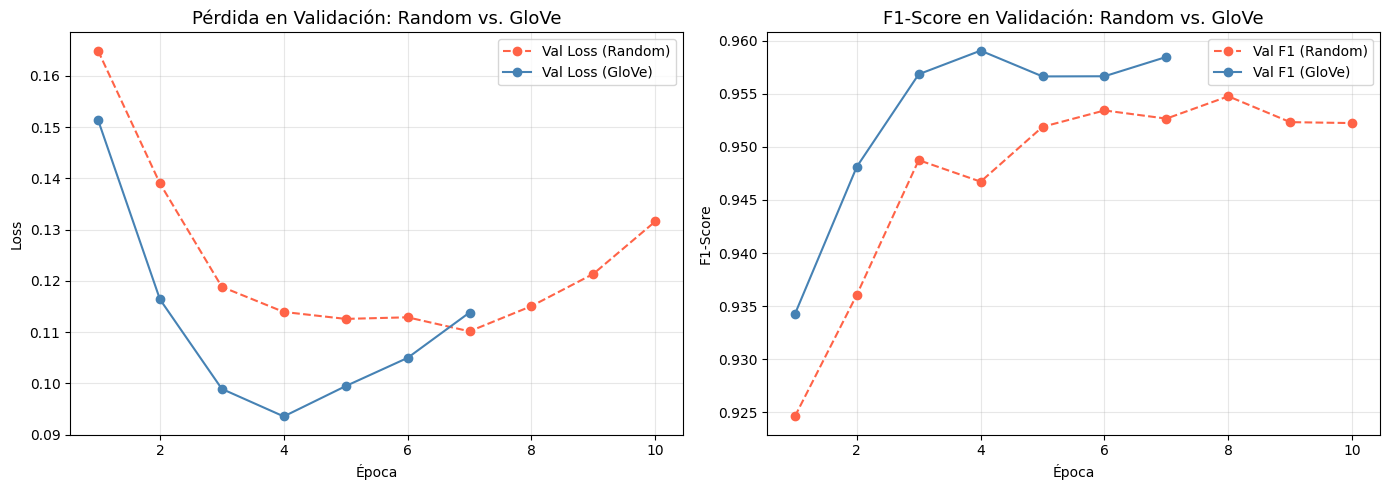

Épocas entrenadas — Random: 10 | GloVe: 7


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_r = range(1, len(history_random['train_loss']) + 1)
epochs_g = range(1, len(history_glove['train_loss'])  + 1)

# --- Curvas de Loss ---
axes[0].plot(epochs_r, history_random['val_loss'], 'o-', label='Val Loss (Random)', color='tomato',   linestyle='--')
axes[0].plot(epochs_g, history_glove['val_loss'],  'o-', label='Val Loss (GloVe)',  color='steelblue')
axes[0].set_title('Pérdida en Validación: Random vs. GloVe', fontsize=13)
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Curvas de F1 ---
axes[1].plot(epochs_r, history_random['val_f1'], 'o-', label='Val F1 (Random)', color='tomato',   linestyle='--')
axes[1].plot(epochs_g, history_glove['val_f1'],  'o-', label='Val F1 (GloVe)',  color='steelblue')
axes[1].set_title('F1-Score en Validación: Random vs. GloVe', fontsize=13)
axes[1].set_xlabel('Época')
axes[1].set_ylabel('F1-Score')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('curvas_random_vs_glove.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Épocas entrenadas — Random: {len(history_random["train_loss"])} | GloVe: {len(history_glove["train_loss"])}')

In [ ]:
metrics_random_test = evaluate_model(model_random, test_loader, criterion, device)
metrics_glove_test  = evaluate_model(model_glove,  test_loader, criterion, device)

print('--- Métricas en Test (Random) ---')
for metric, value in metrics_random_test.items():
    print(f'  {metric:>10s}: {value:.4f}')

print('\n--- Métricas en Test (GloVe) ---')
for metric, value in metrics_glove_test.items():
    print(f'  {metric:>10s}: {value:.4f}')

--- Métricas en Test (Random) ---
        loss: 0.1164
    accuracy: 0.9617
          f1: 0.9568
   precision: 0.9559
      recall: 0.9577

--- Métricas en Test (GloVe) ---
        loss: 0.1046
    accuracy: 0.9635
          f1: 0.9587
   precision: 0.9598
      recall: 0.9577


In [ ]:
# Resultados del Reto 2 — sustituir con los valores reales
# (columna 'Reto 2' con los baselines clásicos)
baselines_reto2 = {
    'Logistic Regression': {'accuracy': 0.971659, 'f1': 0.971672, 'precision': 0.970873, 'recall': 0.971772, 'loss': None},
    'SVM':                 {'accuracy': 0.963026, 'f1': 0.963033, 'precision': 0.962386, 'recall': 0.962699, 'loss': None},
    'Naive Bayes':         {'accuracy': 0.906996, 'f1': 0.907015, 'precision': 0.905615, 'recall': 0.905950, 'loss': None},
}

def fmt(v):
    return f'{v:.4f}' if v is not None else 'N/A'

summary = pd.DataFrame({
    'Métrica': ['Loss (test)', 'Accuracy (test)', 'F1 (test)', 'Precision (test)',
                'Recall (test)', 'Mejor Val F1', 'Épocas entrenadas'],
    'TextCNN Random': [
        fmt(metrics_random_test['loss']),
        fmt(metrics_random_test['accuracy']),
        fmt(metrics_random_test['f1']),
        fmt(metrics_random_test['precision']),
        fmt(metrics_random_test['recall']),
        fmt(max(history_random['val_f1'])),
        str(len(history_random['train_loss'])),
    ],
    'TextCNN GloVe': [
        fmt(metrics_glove_test['loss']),
        fmt(metrics_glove_test['accuracy']),
        fmt(metrics_glove_test['f1']),
        fmt(metrics_glove_test['precision']),
        fmt(metrics_glove_test['recall']),
        fmt(max(history_glove['val_f1'])),
        str(len(history_glove['train_loss'])),
    ],
    'LR (Reto 2)': [
        'N/A', fmt(baselines_reto2['Logistic Regression']['accuracy']),
        fmt(baselines_reto2['Logistic Regression']['f1']),
        fmt(baselines_reto2['Logistic Regression']['precision']),
        fmt(baselines_reto2['Logistic Regression']['recall']), 'N/A', 'N/A',
    ],
    'SVM (Reto 2)': [
        'N/A', fmt(baselines_reto2['SVM']['accuracy']),
        fmt(baselines_reto2['SVM']['f1']),
        fmt(baselines_reto2['SVM']['precision']),
        fmt(baselines_reto2['SVM']['recall']), 'N/A', 'N/A',
    ],
    'NB (Reto 2)': [
        'N/A', fmt(baselines_reto2['Naive Bayes']['accuracy']),
        fmt(baselines_reto2['Naive Bayes']['f1']),
        fmt(baselines_reto2['Naive Bayes']['precision']),
        fmt(baselines_reto2['Naive Bayes']['recall']), 'N/A', 'N/A',
    ],
})

print('=' * 75)
print('   COMPARACIÓN: TextCNN Random vs GloVe vs Baselines Reto 2')
print('=' * 75)
print(summary.to_string(index=False))
print('=' * 75)

   COMPARACIÓN: TextCNN Random vs GloVe vs Baselines Reto 2
          Métrica TextCNN Random TextCNN GloVe LR (Reto 2) SVM (Reto 2) NB (Reto 2)
      Loss (test)         0.1164        0.1046         N/A          N/A         N/A
  Accuracy (test)         0.9617        0.9635      0.9717       0.9630      0.9070
        F1 (test)         0.9568        0.9587      0.9717       0.9630      0.9070
 Precision (test)         0.9559        0.9598      0.9709       0.9624      0.9056
    Recall (test)         0.9577        0.9577      0.9718       0.9627      0.9060
     Mejor Val F1         0.9548        0.9591         N/A          N/A         N/A
Épocas entrenadas             10             7         N/A          N/A         N/A


Mejor modelo: TextCNN con embeddings GloVe (Val F1 = 0.9591)


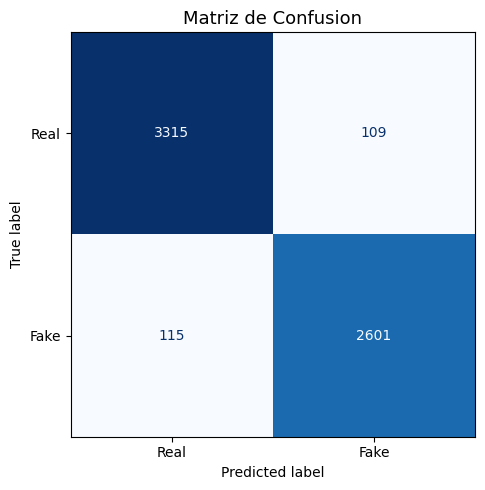

In [ ]:
best_f1_random = max(history_random['val_f1'])
best_f1_glove  = max(history_glove['val_f1'])

if best_f1_glove >= best_f1_random:
    best_model = model_glove
    best_name  = 'GloVe'
    print(f'Mejor modelo: TextCNN con embeddings GloVe (Val F1 = {best_f1_glove:.4f})')
else:
    best_model = model_random
    best_name  = 'Random'
    print(f'Mejor modelo: TextCNN con embeddings Random (Val F1 = {best_f1_random:.4f})')

y_true, y_pred, y_proba = get_predictions(best_model, test_loader, device)
plot_confusion_matrix(y_true, y_pred, labels=['Real', 'Fake'])

# ¿Los embeddings preentrenados convergieron más rápido? ¿Por qué?
Sí, GloVe convergió más rápido. El modelo con embeddings GloVe activó el early stopping en 7 épocas, mientras que el modelo con embeddings aleatorios necesitó las 10 épocas completas sin disparar el criterio de parada. Esto se refleja también en el mejor F1 de validación: GloVe alcanzó 0.9591 contra 0.9548 de Random.
<br>
La razón es que los embeddings aleatorios parten de ruido puro — la red necesita aprender simultáneamente la representación semántica de cada palabra y los patrones de clasificación a partir de cero. Con GloVe, la capa de embedding ya codifica relaciones semánticas útiles antes de empezar a entrenar: palabras como president y government ya están cerca en el espacio vectorial, y términos de incertidumbre como allegedly o reportedly ya ocupan una región distinguible.